# Quantile Regression


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arviz import convert_to_inference_data, summary
from IPython.display import display
from scipy.linalg import inv, solve
from scipy.stats import geninvgauss
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

## Quantile regression model

### 1. Model specification

The 100$\times\alpha$ quantile, $q_{\alpha}$, is defined as

$$
    \mathrm{P}(y \leqq q_{\alpha}) = \alpha,\quad 0 \leqq \alpha \leqq 1.
$$

Suppose $q_{\alpha}$ is expressed as a linear combination of $x$, i.e.,

$$
    \mathrm{P}(y\leqq x^{\intercal}\beta_{\alpha}) = \alpha.
$$
  
Then a **quantile regression** (QR) is formulated as

$$
    y = x^{\intercal}\beta_{\alpha} + \epsilon,\quad \int_{-\infty}^{0}f(\epsilon)d\epsilon = \alpha,
$$

where $f$ is the p.d.f.\ of the error term $\epsilon$.

### 2. QR estimation

The coefficients $\beta$ in QR are estimated by solving the following minimization problem:

$$
    \min_{\beta_{\alpha}}\sum_{i=1}^{n}\rho_{\alpha}\left(y_{i}-x_{i}^{\intercal}\beta_{\alpha}\right),\quad \rho_{\alpha}(u) = u\{\alpha - \mathbb{1}^{-}(u)\},
$$

where $\rho_{\alpha}(\cdot)$ is called the **check function**. Since

$$
    \begin{split}
    \rho_{\alpha}(y_{i}-x_{i}^{\intercal}\beta_{\alpha})
    &= (y_{i}-x_{i}^{\intercal}\beta_{\alpha})\{\alpha - \mathbb{1}^{-}(y_{i}-x_{i}^{\intercal}\beta_{\alpha})\} \\
    &=
      \begin{cases}
        \alpha(y_{i}-x_{i}^{\intercal}\beta_{\alpha}), & \text{if } y_{i} > x_{i}^{\intercal}\beta_{\alpha}; \\
        (\alpha-1)(y_{i}-x_{i}^{\intercal}\beta_{\alpha}), & \text{if } y_{i} \leqq x_{i}^{\intercal}\beta_{\alpha},
      \end{cases}
  \end{split}
$$

QR is equivalent to

$$
    \begin{split}
      \max_{\beta_{\alpha}}\prod_{i=1}^{n}\frac{\alpha(1-\alpha)}{\sigma}
      \exp\biggl[
      & -\frac{\alpha}{\sigma}(y_{i}-x_{i}^{\intercal}\beta_{\alpha})\mathbb{1}^{+}(y_{i}-x_{i}^{\intercal}\beta_{\alpha}) \\
      & -\frac{\alpha-1}{\sigma}(y_{i}-x_{i}^{\intercal}\beta_{\alpha})\mathbb{1}^{-}(y_{i}-x_{i}^{\intercal}\beta_{\alpha})
        \biggr],
    \end{split}
$$

which is the maximum likelihood estimation of the asymmetric Laplace distribution.

### 3. Mixture representation Of the asymmetric Laplace distribution

The asymmetric Laplace distribution can be expressed as a mixture of normal distributions:

$$
    \begin{split}
      & y_{i} = x_{i}^{\intercal}\beta_{\alpha} + \theta z_{i} + \tau \sqrt{\sigma z_{i}} u_{i}, \\
      & z_{i}\sim\mathrm{Exponential}(\sigma),\ \ u_{i}\sim\mathrm{Normal}(0,1),\ z_{i}\perp u_{i}, \\
      & \theta =\frac{1-2\alpha}{\alpha(1-\alpha)},\quad
        \tau^{2} = \frac{2}{\alpha(1-\alpha)}.
    \end{split}
$$

 Note that $\theta$ and $\tau$ are fixed once $\alpha$ is given.

### 4. Full conditional posterior distributions

+ The full conditional of $\beta_{\alpha}$ is the nmultivariate ormal distribution.

$$
    \begin{split}
      & \beta_{\alpha}|\sigma,z,D \sim \mathrm{Normal}\left(\beta_{\star},A_{\star}^{-1}\right), \\
      & A_{\star} = \sum_{i=1}^{n}\frac{x_{i}x_{i}^{\intercal}}{\tau^{2}\sigma z_{i}} + A_{0}, \\
      & \beta_{\star} = A_{\star}^{-1}\left(\sum_{i=1}^{n}\frac{x_{i}(y_{i}-\theta z_{i})}{\tau^{2}\sigma z_{i}}+A_{0}\beta_{0}\right).
    \end{split}
$$

+ The full conditional of $\sigma$ is the inverse gamma distribution:

$$
    \begin{split}
      & \sigma|\beta_{\alpha},z,D \sim \mathrm{Inv.Gamma}\left(\frac{\nu_{\star}}2,\frac{\lambda_{\star}}2\right), \\
      & \nu_{\star} = 3n+\nu_{0}, \quad
        \lambda_{\star} = \sum_{i=1}^{n}\frac{(y_{i}-x_{i}^{\intercal}\beta_{\alpha}-\theta z_{i})^{2}}{\tau^{2}z_{i}}+2\sum_{i=1}^{n}z_{i} + \lambda_{0}.
    \end{split}
$$

+ The full conditional of $z_{i}$ ($i=1,\dots,n$) is the generalized inverse Gaussian distribution:

$$
    \begin{split}
        & z_{i}|\beta_{\alpha}, \sigma, D \sim \mathrm{Gen.Inv.Gauss}\left(\frac12,\hat{a}_{i},\hat{b}_{i}\right), \\
        & \hat{a}_{i} = \frac{\theta^{2}}{\tau^{2}\sigma}+\frac2{\sigma},\quad
          \hat{b}_{i} = \frac{(y_{i}-x_{i}^{\intercal}\beta_{\alpha})^{2}}{\tau^{2}\sigma}.
    \end{split}
$$


In [3]:
def gibbs_qr(y, X, a, hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for Bayesian ridge regression

    Inputs
    y       --- regressand (n x 1)
    X       --- regressors (n x k)
    a       --- quantile probability
    hyper_param = [b0, A0, nu0, lam0]
    b0      --- the prior mean vector of the regression coefficients
    A0      --- the prior precision matrix of the regression coefficients
    nu0     --- the prior shape parameter for the error variance
    lam0    --- the prior scale parameter for the error variance
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample (draws x (k + 1))
                column 0:(k-1)    regression coefficients
                column k          error variance
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    b0, A0, nu0, lam0 = hyper_param
    n, k = X.shape
    nu_star = 0.5 * (3.0 * n + nu0)
    A0b0 = A0 @ b0
    theta = (1.0 - 2.0 * a) / (a * (1.0 - a))
    tau2 = 2.0 / (a * (1.0 - a))
    a0 = theta ** 2 / tau2 + 2.0
    b = solve(X.T @ X, X.T @ y)
    sigma2 = np.square(y - X @ b).sum() / (n - k)
    runs = np.empty((iterations, k + 1))
    for it in trange(iterations):
        a_hat = a0 / sigma2
        b_hat = np.square(y - X @ b) / (tau2 * sigma2)
        xi = np.sqrt(a_hat * b_hat)
        eta = np.sqrt(b_hat / a_hat)
        z = geninvgauss.rvs(0.5, xi, scale=eta, random_state=rng)
        cov_b = inv(X.T @ (X / np.tile(z.reshape(-1, 1), k)) / (tau2 * sigma2) + A0)
        mean_b = cov_b @ (X.T @ (y / z - theta) / (tau2 * sigma2) + A0b0)
        b = rng.multivariate_normal(mean_b, cov_b)
        lam_star = 0.5 * ((np.square(y - X @ b - theta * z) / z).sum() / tau2 + 2.0 * z.sum() + lam0)
        sigma2 = lam_star / rng.gamma(nu_star)
        runs[it, :-1] = b
        runs[it, -1] = sigma2
    return runs

## Major League Baseball Data - Hitters.csv

Major League Baseball Data from the 1986 and 1987 seasons.

A data frame with 322 observations of major league players on the following 20 variables.

### Variables

+ AtBat - Number of times at bat in 1986
+ Hits - Number of hits in 1986
+ HmRun - Number of home runs in 1986
+ Runs - Number of runs in 1986
+ RBI - Number of runs batted in in 1986
+ Walks - Number of walks in 1986
+ Years - Number of years in the major leagues
+ CAtBat - Number of times at bat during his career
+ CHits - Number of hits during his career
+ CHmRun - Number of home runs during his career
+ CRuns - Number of runs during his career
+ CRBI - Number of runs batted in during his career
+ CWalks - Number of walks during his career
+ League - A factor with levels A and N indicating player's league at the end of 1986
+ Division - A factor with levels E and W indicating player's division at the end of 1986
+ PutOuts - Number of put outs in 1986
+ Assists - Number of assists in 1986
+ Errors - Number of errors in 1986
+ Salary - 1987 annual salary on opening day in thousands of dollars
+ NewLeague - A factor with levels A and N indicating player's league at the beginning of 1987

### Source
This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University. This is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

### References
James, G., Witten, D., Hastie, T., and Tibshirani, R. (2013) An Introduction to Statistical Learning with applications in R, https://www.statlearning.com, Springer-Verlag, New York

In [4]:
data = pd.read_csv('Hitters.csv')
display(data)
missing = data['Salary'].isna()
y = np.log(data['Salary'].to_numpy()[~missing])
n = len(y)
X = np.hstack((np.ones((n, 1)), data[['AtBat','Hits','HmRun','Walks','Years','PutOuts']].to_numpy()[~missing, :]))
varnames = ['Constant','AtBat','Hits','HmRun','Walks','Years','PutOuts','$\\sigma^{2}$']

,rownames,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,-Willie McGee,497,127,7,65,48,37,5,2703,806,...,379,311,138,N,E,325,9,3,700.0,N
318,-Willie Randolph,492,136,5,76,50,94,12,5511,1511,...,897,451,875,A,E,313,381,20,875.0,A
319,-Wayne Tolleson,475,126,3,61,43,52,6,1700,433,...,217,93,146,A,W,37,113,7,385.0,A
320,-Willie Upshaw,573,144,9,85,60,78,8,3198,857,...,470,420,332,A,E,1314,131,12,960.0,A


### Quantile Regression Model of Players' Salary

$$
  \log (\text{Salary}) = \beta_{0} + \beta_{1}\text{AtBat} + \beta_{2}\text{Hits} + \beta_{3}\text{HmRun}
  + \beta_{4}\text{Walks} + \beta_{5}\text{Years} + \beta_{6}\text{PutOuts} + \text{Error Term}.
$$


In [5]:
rng = np.random.default_rng(seed=99)
k = X.shape[1]
b0 = np.zeros(k)
A0 = 0.2 * np.eye(k)
nu0 = 0.002
lam0 = 0.002
hyper_param = [b0, A0, nu0, lam0]
burnin = 1000
draws = 10000
alpha = np.array([0.1, 0.25, 0.5, 0.75, 0.9])
sim_param_qr = {a: gibbs_qr(y, X, a, hyper_param, burnin=burnin, draws=draws, rng=rng) for a in alpha}

100%|████████████████████████████████████████████████████████████████████████████| 11000/11000 [05:31<00:00, 33.17it/s]


In [6]:
results_qr = {a: mcmc_stats(sim_param_qr[a], burnin=burnin, param_string=varnames) for a in alpha}
for a in alpha:
    print(f'Quantile = {100 * a} %')
    display(results_qr[a])

Quantile = 10.0 %


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,3.689,0.085,3.518,3.847,0.002,0.001,1387.0,2900.0,1.00
AtBat,-0.003,0.001,-0.005,-0.001,0.000,0.000,1167.0,2574.0,1.01
Hits,0.016,0.003,0.011,0.022,0.000,0.000,1162.0,2404.0,1.01
HmRun,-0.001,0.004,-0.010,0.007,0.000,0.000,1297.0,2770.0,1.00
Walks,0.007,0.002,0.004,0.011,0.000,0.000,1149.0,2597.0,1.01
Years,0.092,0.004,0.084,0.101,0.000,0.000,1780.0,3586.0,1.00
PutOuts,-0.000,0.000,-0.000,0.000,0.000,0.000,1644.0,3354.0,1.00
$\sigma^{2}$,0.097,0.006,0.085,0.109,0.000,0.000,4167.0,7067.0,1.00


Quantile = 25.0 %


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,3.724,0.094,3.537,3.910,0.002,0.001,2312.0,4061.0,1.0
AtBat,-0.003,0.001,-0.004,-0.001,0.000,0.000,2020.0,3928.0,1.0
Hits,0.016,0.003,0.011,0.022,0.000,0.000,1887.0,3538.0,1.0
HmRun,-0.000,0.004,-0.009,0.008,0.000,0.000,2211.0,4026.0,1.0
Walks,0.008,0.002,0.004,0.012,0.000,0.000,1842.0,2984.0,1.0
Years,0.103,0.006,0.090,0.114,0.000,0.000,2004.0,3841.0,1.0
PutOuts,-0.000,0.000,-0.000,0.000,0.000,0.000,2004.0,2770.0,1.0
$\sigma^{2}$,0.184,0.011,0.162,0.207,0.000,0.000,4853.0,7507.0,1.0


Quantile = 50.0 %


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,3.992,0.181,3.636,4.337,0.006,0.003,1001.0,1913.0,1.01
AtBat,-0.002,0.001,-0.004,0.000,0.000,0.000,2138.0,3943.0,1.00
Hits,0.014,0.003,0.008,0.020,0.000,0.000,2227.0,3870.0,1.00
HmRun,0.000,0.006,-0.012,0.012,0.000,0.000,1523.0,2905.0,1.00
Walks,0.008,0.002,0.003,0.012,0.000,0.000,1729.0,3735.0,1.00
Years,0.107,0.010,0.087,0.125,0.000,0.000,1388.0,2999.0,1.01
PutOuts,0.000,0.000,0.000,0.001,0.000,0.000,2273.0,4053.0,1.00
$\sigma^{2}$,0.248,0.015,0.219,0.277,0.000,0.000,4747.0,7688.0,1.00


Quantile = 75.0 %


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,4.600,0.112,4.372,4.821,0.002,0.001,2121.0,3426.0,1.0
AtBat,-0.001,0.001,-0.003,0.001,0.000,0.000,2122.0,3742.0,1.0
Hits,0.009,0.003,0.004,0.015,0.000,0.000,2072.0,3739.0,1.0
HmRun,0.015,0.005,0.006,0.024,0.000,0.000,2100.0,4017.0,1.0
Walks,0.007,0.002,0.003,0.011,0.000,0.000,2182.0,3795.0,1.0
Years,0.090,0.010,0.070,0.109,0.000,0.000,1534.0,2719.0,1.0
PutOuts,0.000,0.000,0.000,0.001,0.000,0.000,1512.0,3103.0,1.0
$\sigma^{2}$,0.186,0.012,0.164,0.209,0.000,0.000,4507.0,6842.0,1.0


Quantile = 90.0 %


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,5.188,0.196,4.819,5.577,0.008,0.004,544.0,1386.0,1.01
AtBat,-0.002,0.001,-0.003,-0.000,0.000,0.000,1192.0,1943.0,1.00
Hits,0.009,0.002,0.005,0.014,0.000,0.000,1739.0,3136.0,1.00
HmRun,0.013,0.005,0.003,0.021,0.000,0.000,1479.0,2514.0,1.00
Walks,0.007,0.002,0.003,0.011,0.000,0.000,1343.0,2775.0,1.01
Years,0.082,0.014,0.056,0.110,0.001,0.000,632.0,1052.0,1.00
PutOuts,0.000,0.000,0.000,0.001,0.000,0.000,1546.0,3312.0,1.00
$\sigma^{2}$,0.105,0.007,0.093,0.118,0.000,0.000,4804.0,7533.0,1.00


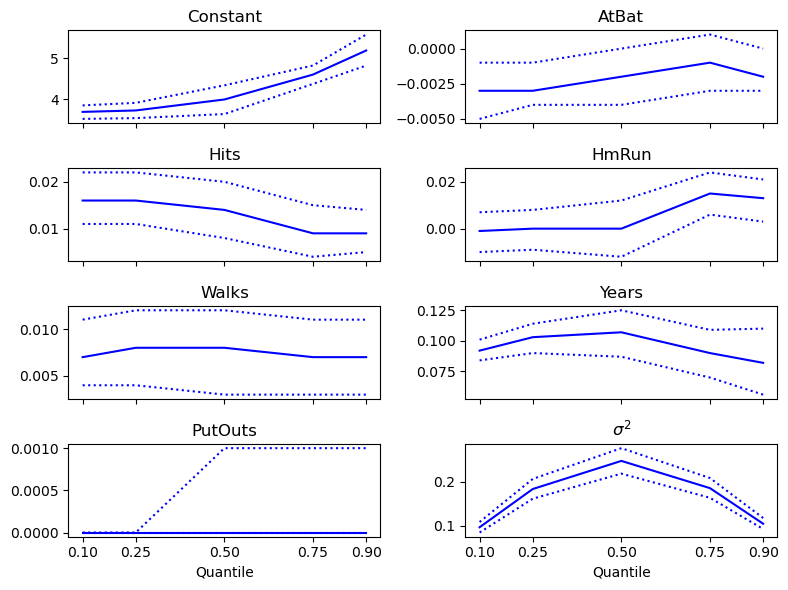

In [7]:
post_mean = np.array([results_qr[a]['mean'].to_numpy() for a in alpha])
lb_hpdi = np.array([results_qr[a]['hdi_2.5%'].to_numpy() for a in alpha])
ub_hpdi = np.array([results_qr[a]['hdi_97.5%'].to_numpy() for a in alpha])
num_row = 4
num_col = 2
fig, ax = plt.subplots(num_row, num_col, num=1, sharex='col', figsize=(8, 1.5*num_row), facecolor='w')
row = 0
col = 0
for idx in range(k+1):
    ax[row, col].plot(alpha, post_mean[:, idx], 'b-')
    ax[row, col].plot(alpha, lb_hpdi[:, idx], 'b:')
    ax[row, col].plot(alpha, ub_hpdi[:, idx], 'b:')
    ax[row, col].set_title(varnames[idx])
    ax[row, col].set_xticks(ticks=alpha)
    if row == num_row-1:
        ax[row, col].set_xlabel('Quantile')
    if (idx+1) % num_col > 0:
        col += 1
    else:
        row += 1
        col = 0 
plt.tight_layout()
plt.show()